<a href="https://colab.research.google.com/github/Jake0925/DeepLearning/blob/master/%EA%B2%BD%EC%82%AC%ED%95%98%EA%B0%95%EB%B2%95%EA%B5%AC%ED%98%84%EB%B0%8F_%EC%8B%AC%ED%94%8C%EC%98%88%EC%A9%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/deeplearningzerotoall/TensorFlow/blob/master/tf_2.x/lab-02-1-Simple-Linear-Regression-eager.ipynb

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.18.0


In [3]:
# reduce_mean을 통한 평균값 구하기 테스트
v =[1., 2., 3., 4.]
tf.reduce_mean(v) # 2.5 ,  reduce란 차원을 줄인다는 의미로 v가 1차원데이터인데 0차원으로 줄여져 2.5라는 값만 출력된다

<tf.Tensor: shape=(), dtype=float32, numpy=2.5>

In [4]:
# square을 통해 제곱승값 구하기 테스트
tf.square(3) # 9, square는 제곱승을 의미한다

<tf.Tensor: shape=(), dtype=int32, numpy=9>

In [5]:
x_data = [1, 2, 3, 4, 5]
y_data = [1, 2, 3, 4, 5]

W = tf.Variable(2.0) # 임의의 W값
b = tf.Variable(0.5) # 임의의 b값

hypothesis = W * x_data + b

In [6]:
# W, b값 출력
W.numpy(), b.numpy()

(2.0, 0.5)

In [7]:
# 예측값 출력
hypothesis.numpy()

array([ 2.5,  4.5,  6.5,  8.5, 10.5], dtype=float32)

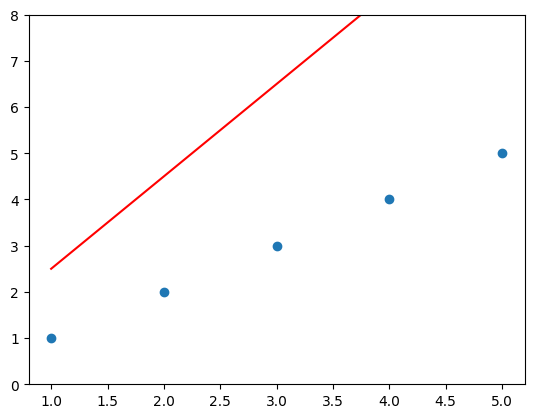

In [10]:
plt.plot(x_data, hypothesis.numpy(), 'r-')
plt.plot(x_data, y_data, 'o')
plt.ylim(0, 8)
plt.show()

# Cost

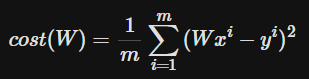

In [11]:
cost = tf.reduce_mean(tf.square(hypothesis - y_data)) # 위의 비용함수 공식 구현

with구문
- with문 안의 변수들의 변화되는 모든 값들을 tape에 저장한다
- 예제의 경우 변수 W, b에 대한 값들을 tape에 기록하게 된다

tf.GradientTape() 구문
- 경사하강법을 구현한 것이

In [12]:
with tf.GradientTape() as tape:
    hypothesis = W * x_data + b
    cost = tf.reduce_mean(tf.square(hypothesis - y_data))

W_grad, b_grad = tape.gradient(cost, [W, b]) # W와 b에 대한 미분값을 구하여 tuple로 반환한다
W_grad.numpy(), b_grad.numpy()

(25.0, 7.0)

파라미터 업데이트
- 미분값과 learning rate값을 적용하여 W, b값을 업데이트 해준다

assign_sub구문
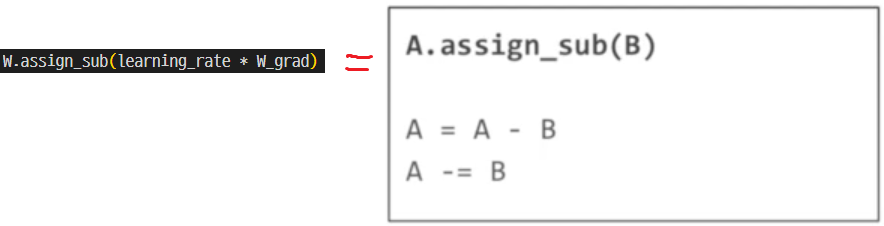

In [13]:
learning_rate = 0.01 # 학습율

W.assign_sub(learning_rate * W_grad)
b.assign_sub(learning_rate * b_grad)

W.numpy(), b.numpy()

(1.75, 0.43)

(0.0, 8.0)

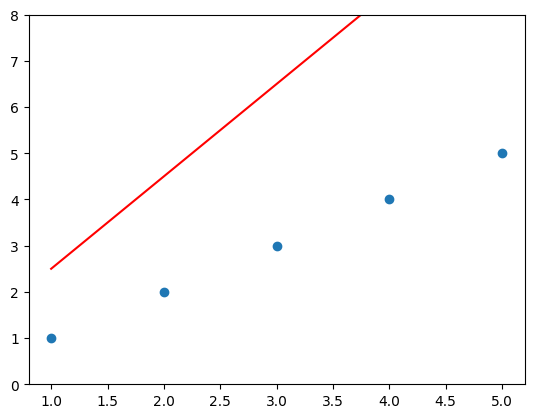

In [14]:
plt.plot(x_data, hypothesis.numpy(), 'r-')
plt.plot(x_data, y_data, 'o')
plt.ylim(0, 8)

여러 번 반복 수행

    0|    2.4520|    0.3760| 45.660004
   10|    1.1036|    0.0034|  0.206336
   20|    1.0128|   -0.0209|  0.001026
   30|    1.0065|   -0.0218|  0.000093
   40|    1.0059|   -0.0212|  0.000083
   50|    1.0057|   -0.0205|  0.000077
   60|    1.0055|   -0.0198|  0.000072
   70|    1.0053|   -0.0192|  0.000067
   80|    1.0051|   -0.0185|  0.000063
   90|    1.0050|   -0.0179|  0.000059


(0.0, 8.0)

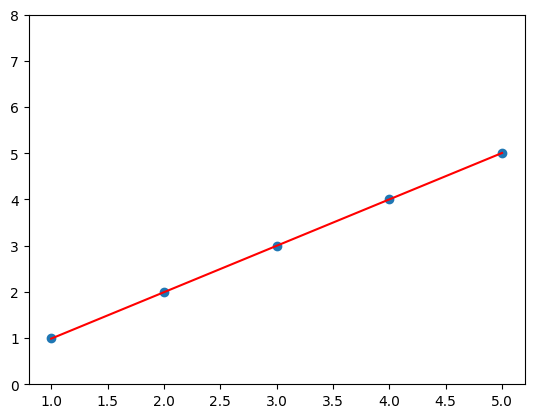

In [15]:
W = tf.Variable(2.9)
b = tf.Variable(0.5)

for i in range(100): # 100번 수행
    with tf.GradientTape() as tape:
        hypothesis = W * x_data + b
        cost = tf.reduce_mean(tf.square(hypothesis - y_data))
    W_grad, b_grad = tape.gradient(cost, [W, b])
    W.assign_sub(learning_rate * W_grad)
    b.assign_sub(learning_rate * b_grad)
    if i % 10 == 0: # i값이 10의배수일때마다 표시
      print("{:5}|{:10.4f}|{:10.4f}|{:10.6f}".format(i, W.numpy(), b.numpy(), cost))

plt.plot(x_data, y_data, 'o')
plt.plot(x_data, hypothesis.numpy(), 'r-')
plt.ylim(0, 8)

예측
- 위의 공식을 통해 구해진 W, b값을 사용하여 임의의 x(입력값)값을 입력하여 출력값을 확인해보자

In [16]:
print(W * 5 + b)
print(W * 2.5 + b)

tf.Tensor(5.0066934, shape=(), dtype=float32)
tf.Tensor(2.4946523, shape=(), dtype=float32)


전체코드

In [17]:
import tensorflow as tf
import numpy as np

# Data
x_data = [1, 2, 3, 4, 5]
y_data = [1, 2, 3, 4, 5]

# W, b initialize
W = tf.Variable(2.9)
b = tf.Variable(0.5)

# W, b update
for i in range(100):
    # Gradient descent
    with tf.GradientTape() as tape:
        hypothesis = W * x_data + b
        cost = tf.reduce_mean(tf.square(hypothesis - y_data))
    W_grad, b_grad = tape.gradient(cost, [W, b])
    W.assign_sub(learning_rate * W_grad)
    b.assign_sub(learning_rate * b_grad)
    if i % 10 == 0:
      print("{:5}|{:10.4f}|{:10.4f}|{:10.6f}".format(i, W.numpy(), b.numpy(), cost))

print()

# predict
print(W * 5 + b)
print(W * 2.5 + b)

    0|    2.4520|    0.3760| 45.660004
   10|    1.1036|    0.0034|  0.206336
   20|    1.0128|   -0.0209|  0.001026
   30|    1.0065|   -0.0218|  0.000093
   40|    1.0059|   -0.0212|  0.000083
   50|    1.0057|   -0.0205|  0.000077
   60|    1.0055|   -0.0198|  0.000072
   70|    1.0053|   -0.0192|  0.000067
   80|    1.0051|   -0.0185|  0.000063
   90|    1.0050|   -0.0179|  0.000059

tf.Tensor(5.0066934, shape=(), dtype=float32)
tf.Tensor(2.4946523, shape=(), dtype=float32)
